<a href="https://colab.research.google.com/github/tsvlgd/MLE/blob/main/6.dataset%26dataloader/pytorch_training_pipeline_using_dataset_and_dataloader.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# minibatch gradient descent
"""
assumption:
  - X_train_tensor
  - y_train_tensor
"""

batch_size = 32
num_samples = len(X_train_tensor)  # eg : 100
epochs = 25

for epoch in range(epochs):

  for start_index in range(0, num_samples, batch_size):

    end_index = start_index + batch_size

    X_batch = X_train_tensor [start_index:end_index]
    y_batch = y_train_tensor [start_index:end_index]

    y_pred = model(X_batch)
    loss = loss_func()

    # update
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

"""
problems:
1. No standard interface for data
2. No easy way to apply transformations
3. Shuffling and sampling
4. Batch management & Parallelization


introducing: Dataset and DataLoader class ->
"""

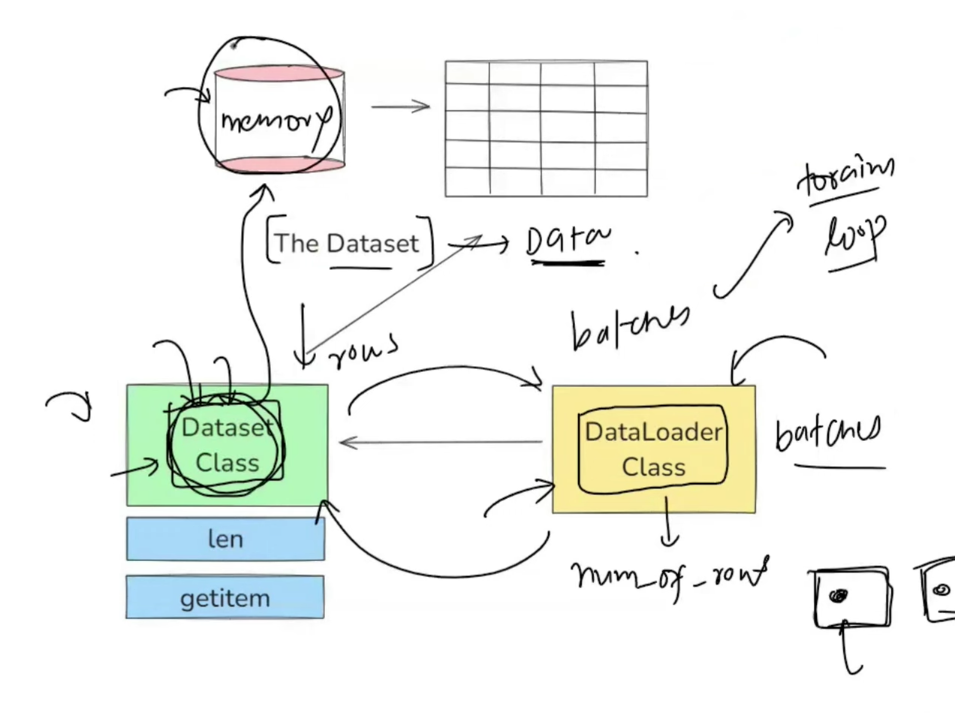

In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
df.shape

(569, 33)

In [6]:
df.drop(columns=['id', 'Unnamed: 32'], inplace= True)

KeyError: "['id', 'Unnamed: 32'] not found in axis"

In [7]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### train test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size=0.2)

### scaling

In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train

array([[-7.71894460e-01,  4.78538330e-01, -7.85109982e-01, ...,
        -4.65118302e-01, -9.40920694e-02,  2.08137278e-01],
       [-8.29287899e-01, -1.22201699e+00, -8.36762256e-01, ...,
        -1.12351334e+00, -5.21872818e-01, -7.82876552e-01],
       [ 5.71112026e-01,  9.46841464e-01,  4.73705913e-01, ...,
        -2.08622347e-01,  1.07117058e-01,  5.37909296e-04],
       ...,
       [ 1.27131199e+00, -1.69517521e-01,  1.24015901e+00, ...,
         7.65518156e-01,  1.37016931e+00,  6.99198037e-02],
       [-6.65716597e-01, -4.84084778e-01, -6.93468851e-01, ...,
        -5.52084428e-02, -5.28636150e-01, -7.39717735e-01],
       [ 6.39984153e-01,  6.25178706e-01,  6.73650198e-01, ...,
        -1.33804728e-01, -2.51339538e-01, -2.72072841e-01]])

In [ ]:
y_train

,diagnosis
109,B
354,B
10,M
173,B
73,M
...,...
531,B
534,B
85,M
187,B


### Label Encoding

In [10]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

In [11]:
y_train

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,

### Numpy arrays to PyTorch tensors

In [12]:
X_train_tensor = torch.from_numpy(X_train.astype(np.float32))
X_test_tensor = torch.from_numpy(X_test.astype(np.float32))
y_train_tensor = torch.from_numpy(y_train.astype(np.float32))
y_test_tensor = torch.from_numpy(y_test.astype(np.float32))

In [13]:
X_train_tensor.shape

torch.Size([455, 30])

In [14]:
y_train_tensor.shape

torch.Size([455])

In [15]:
from torch.utils.data import Dataset, DataLoader

class CustomDataset(Dataset):

  def __init__(self, features, labels):

    self.features = features
    self.labels = labels

  def __len__(self):

    return len(self.features)

  def __getitem__(self, idx):

    return self.features[idx], self.labels[idx]



In [16]:
train_dataset = CustomDataset(X_train_tensor, y_train_tensor)
test_dataset = CustomDataset(X_test_tensor, y_test_tensor)

In [17]:
train_dataset[10]

(tensor([-0.1081, -0.3317, -0.1575, -0.1955, -1.1966, -0.8013, -0.7707, -0.9272,
         -1.2739, -1.0053, -0.5482, -0.8385, -0.6267, -0.4017, -1.4294, -0.5506,
         -0.4528, -0.9651, -0.9187, -0.6981, -0.1892, -0.5131, -0.2977, -0.2663,
         -1.5176, -0.4646, -0.5528, -0.8307, -0.8895, -0.7642]),
 tensor(0.))

In [18]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

### Defining the model

In [19]:
import torch.nn as nn


class MySimpleNN(nn.Module):

  def __init__(self, num_features):

    super().__init__()
    self.linear = nn.Linear(num_features, 1)
    self.sigmoid = nn.Sigmoid()

  def forward(self, features):

    out = self.linear(features)
    out = self.sigmoid(out)

    return out

### Important Parameters

In [20]:
learning_rate = 0.1
epochs = 25

In [21]:
# create model
model = MySimpleNN(X_train_tensor.shape[1])

# define optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# define loss function
loss_function = nn.BCELoss()

### Training Pipeline

In [22]:

# define loop
for epoch in range(epochs):

  for batch_features, batch_labels in train_loader:

    # forward pass
    y_pred = model(batch_features)

    # loss calculate
    loss = loss_function(y_pred, batch_labels.view(-1,1))

    # clear gradients
    optimizer.zero_grad()

    # backward pass
    loss.backward()

    # parameters update
    optimizer.step()

  # print loss in each epoch
  print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')

Epoch: 1, Loss: 0.1965210735797882
Epoch: 2, Loss: 0.40876850485801697
Epoch: 3, Loss: 0.10313593596220016
Epoch: 4, Loss: 0.18230439722537994
Epoch: 5, Loss: 0.05808422714471817
Epoch: 6, Loss: 0.2808495759963989
Epoch: 7, Loss: 0.1115388497710228
Epoch: 8, Loss: 0.028025776147842407
Epoch: 9, Loss: 0.12020586431026459
Epoch: 10, Loss: 0.08944398909807205
Epoch: 11, Loss: 0.07488824427127838
Epoch: 12, Loss: 0.03164764493703842
Epoch: 13, Loss: 0.2933172583580017
Epoch: 14, Loss: 0.04214200749993324
Epoch: 15, Loss: 0.05036312714219093
Epoch: 16, Loss: 0.00659490330144763
Epoch: 17, Loss: 0.06376290321350098
Epoch: 18, Loss: 0.10031717270612717
Epoch: 19, Loss: 0.1453821361064911
Epoch: 20, Loss: 0.00588183244690299
Epoch: 21, Loss: 0.00880338717252016
Epoch: 22, Loss: 0.09919852763414383
Epoch: 23, Loss: 0.427460640668869
Epoch: 24, Loss: 0.0135319409891963
Epoch: 25, Loss: 0.016590138897299767


### Evaluation

In [24]:
# Model evaluation using test_loader
model.eval()  # Set the model to evaluation mode
accuracy_list = []

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        # Forward pass
        y_pred = model(batch_features)
        y_pred = (y_pred > 0.8).float()  # Convert probabilities to binary predictions

        # Calculate accuracy for the current batch
        batch_accuracy = (y_pred.view(-1) == batch_labels).float().mean().item()
        accuracy_list.append(batch_accuracy)

# Calculate overall accuracy
overall_accuracy = sum(accuracy_list) / len(accuracy_list)
print(f'Accuracy: {overall_accuracy:.4f}')


Accuracy: 0.9470
